<a href="https://colab.research.google.com/github/Meghnashankr23/3DVSS_June2026/blob/main/Articulated_Human_body/Articulated_Human_body.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMPLX Model Visualization and Animation

This notebook demonstrates how to load, manipulate, visualize and animate the SMPLX human body model using Python libraries like `smplx`, `trimesh`, and `plotly`. It covers setting up the environment, adjusting body shape and pose parameters, and creating interactive 3D animations.
Pose Variations
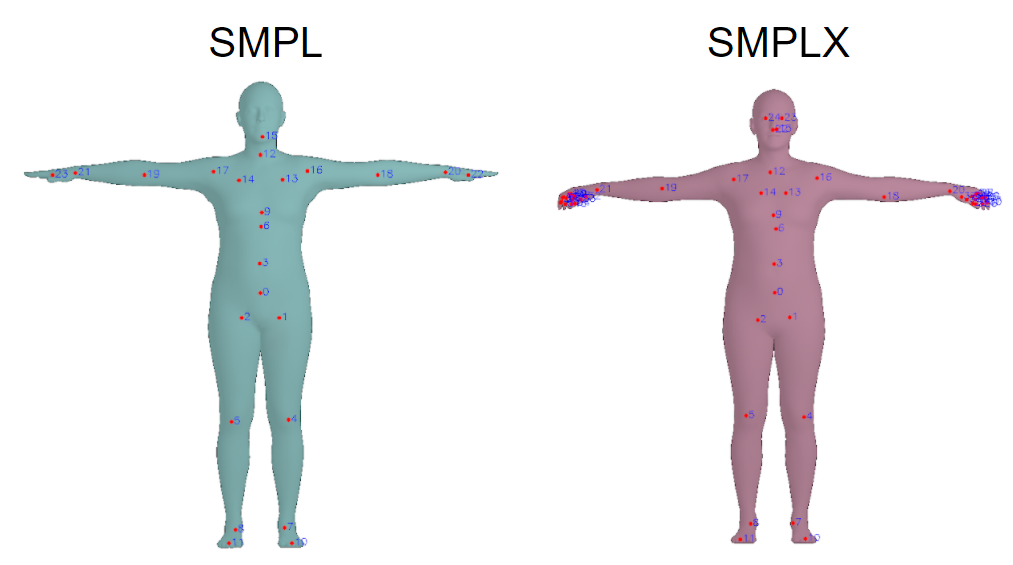

Image Source: https://github.com/facebookresearch/frankmocap/issues/91

### Initial Setup: Install Libraries
This cell installs necessary Python libraries: `smplx` for SMPL-X model functionality and `trimesh` for 3D mesh processing and visualization.

In [ ]:
!pip install smplx trimesh

### Core Library Imports
This cell imports essential libraries for working with the SMPLX model, including `smplx` for model functionality, `numpy` for numerical operations, `torch` for tensor computations, and `trimesh` for 3D mesh processing.

In [ ]:
import smplx
import numpy as np
import torch
import trimesh

### Download SMPLX Model Files
This cell utilizes `gdown` to download the necessary SMPLX model files from a Google Drive folder into the `/content` directory. It uses a predefined `folder_id` and `output_path` to retrieve the model assets required for the SMPLX model instantiation.

In [ ]:
!pip install gdown
import gdown

folder_id = '1uO11lmJbaGnfaSJPj2U61o0Ru_jDrSyu'
output_path = '/content'

gdown.download_folder(id=folder_id, output=output_path, quiet=False, use_cookies=False)
print(f"Folder downloaded to {output_path}/")

### Initialize SMPLX Model
This cell initializes the SMPLX model. It specifies the path to the model files, the model type ('smplx'), gender, and other parameters like `use_pca` and `batch_size`. The `model_path` is currently set to `/content`, implying the model files are expected to be present in the Colab environment's root directory.

In [ ]:
import torch
import smplx

# 1. Define the path to your .npz model file
model_path = "/content"

# 2. Extract the extension and specify the gender
ext = model_path.split('.')[-1]  # will be 'npz'
gender = "neutral"

# 3. Instantiate the SMPLX PyTorch module
model = smplx.create(
    model_path=model_path,
    model_type='smplx',             # Explicitly tell smplx to look for .npz instead of .pkl
    gender=gender,
    use_pca = False,
    batch_size=1          # Adjust body shape parameters if needed
)

### Inspect Model Output
After initializing the SMPLX model, this cell calls the model to get its default output (vertices and joints) and prints their respective shapes. This helps verify the model is working and understand the dimensions of its primary outputs.

In [ ]:
import trimesh
output = model()

verts = output.vertices
joints = output.joints

print(verts.shape)
print(joints.shape)

### Helper Function for Mesh Generation
This cell defines a utility function `generate` that takes the `smplx` model and its output, extracts the vertices and faces, and creates a `trimesh.Trimesh` object. This simplifies the process of visualizing the 3D body.

In [ ]:
def generate(model,output):
  faces = model.faces
  vertices = output.vertices[0].detach().cpu().numpy()
  # 4. Create and display the Trimesh object
  mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
  return mesh


### Manipulating Body Pose (Torso Twist)
This cell demonstrates how to adjust the `body_pose` parameters of the SMPLX model. Specifically, it applies a `0.8` rotation to the torso (index 2 of the `body_pose` vector) and visualizes the resulting mesh, showing how a single parameter can alter the model's posture.

In [ ]:
## Pose
body_pose = torch.zeros((1, 63))
body_pose[0, 2] = 0.8      # torso twist

output = model(body_pose=body_pose)
mesh = generate(model,output)
mesh.show()
#verts = output.vertices
#faces = model.faces

### Manipulating Body Shape
This cell demonstrates how to adjust the body's shape using the `betas` parameters. It specifically sets the first `beta` parameter to `19.0`, which typically influences a major component of body shape variation, and then visualizes the resulting altered mesh.

In [ ]:
## Shape
betas = torch.zeros((1, 10))
betas[0, 0] = 19.0

output = model(betas=betas)
#verts = output.vertices
mesh = generate(model,output)
mesh.show()

### Visualize Joints on the Mesh
This cell uses `plotly.graph_objects` to create an interactive 3D visualization of the SMPLX mesh with its joints. The mesh is rendered with a translucent opacity, and the joints are marked as red spheres, allowing for a clear view of their positions relative to the body surface.

In [ ]:
## Visualize joints on the mesh
import plotly.graph_objects as go

verts = output.vertices.detach().cpu().numpy()[0]
joints = output.joints.detach().cpu().numpy()[0]
faces = model.faces

fig = go.Figure()

# Translucent SMPL mesh
fig.add_trace(
    go.Mesh3d(
        x=verts[:,0],
        y=verts[:,1],
        z=verts[:,2],
        i=faces[:,0],
        j=faces[:,1],
        k=faces[:,2],
        opacity=0.25,
        flatshading=True
    )
)

# Joints
fig.add_trace(
    go.Scatter3d(
        x=joints[:,0],
        y=joints[:,1],
        z=joints[:,2],
        mode='markers',
        marker=dict(
            size=5,
            color='red'
        )
    )
)

fig.update_layout(
    scene=dict(
        aspectmode='data',
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    ),
    width=800,
    height=800,
    margin=dict(l=0,r=0,t=0,b=0)
)

fig.show()

### Install Plotly and Imageio
This cell ensures that `plotly` and `imageio` libraries are installed. `plotly` is used for creating interactive visualizations, and `imageio` is often used for creating GIFs or video from a sequence of images (though in this case, Plotly's animation features are directly used).

In [ ]:
!pip install plotly imageio


### Create Interactive Animation
This cell builds upon the previous step by creating an interactive animation from the generated `frames`. It constructs a Plotly figure with playback controls, allowing the user to play, pause, and step through the body pose variations. This provides a dynamic view of how changes in a single pose parameter affect the body.

In [ ]:
import numpy as np
import torch
import plotly.graph_objects as go

faces = model.faces
frames = []

for a in np.linspace(-1, 1, 20):
    body_pose = torch.zeros((1, 63))   # SMPL-X
    body_pose[0, 50] = a               # arm/hand motion

    output = model(body_pose=body_pose)
    verts = output.vertices.detach().cpu().numpy()[0]

    frames.append(go.Frame(data=[
        go.Mesh3d(
            x=verts[:,0],
            y=verts[:,1],
            z=verts[:,2],
            i=faces[:,0],
            j=faces[:,1],
            k=faces[:,2],
            opacity=1.0
        )
    ]))

# first frame
verts0 = frames[0].data[0]

fig = go.Figure(
    data=[verts0],
    frames=frames
)

fig.update_layout(
    scene=dict(
        aspectmode="data",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    ),
    width=700,
    height=700,
    margin=dict(l=0,r=0,t=0,b=0),
    updatemenus=[dict(
        type="buttons",
        buttons=[
            dict(
                label="Play",
                method="animate",
                args=[None, {
                    "frame": {"duration": 80, "redraw": True},
                    "fromcurrent": True
                }]
            ),
            dict(
                label="Pause",
                method="animate",
                args=[[None], {
                    "frame": {"duration": 0, "redraw": False},
                    "mode": "immediate"
                }]
            )
        ]
    )]
)

fig.show()

### Define Custom Poses and Interpolation
This cell introduces functions to create specific body poses (e.g., 'tree', 'warrior') by setting various `body_pose` parameters. It also defines an `interp` function to smoothly interpolate between two poses, creating a sequence of intermediate poses for animation. These interpolated poses form `pose_seq`.

In [ ]:
import numpy as np
import torch
import plotly.graph_objects as go

faces = model.faces

def make_pose(name):
    pose = torch.zeros((1, 63))   # SMPL-X body_pose

    if name == "twisted_chair":

        # squat
        pose[0,3]  = 0.8      # left hip
        pose[0,6]  = 0.8      # right hip

        pose[0,12] = -1.6     # left knee
        pose[0,15] = -1.6     # right knee

        # torso twist
        pose[0,2]  = 0.9      # root/spine yaw

        # slight forward lean
        pose[0,0]  = 0.7

        # arms in prayer
        pose[0,48] = -0.8
        pose[0,51] = -0.8

        # elbows folded
        pose[0,54] = -1.0
        pose[0,57] =  1.0

    if name == "reverse_warrior":

        # lunge
        pose[0,3]  = 0.7
        pose[0,12] = -1.4

        pose[0,6]  = -0.3
        pose[0,15] = -0.2

        # side bend
        pose[0,1]  = -0.8

        # torso rotation
        pose[0,2]  = 0.5

        # one arm overhead
        pose[0,48] = -2.3

        # other arm down
        pose[0,51] = 0.6

    if name == "archer":

        # wide stance
        pose[0,3]  = 0.6
        pose[0,6]  = -0.6

        pose[0,12] = -1.0
        pose[0,15] = -0.3

        # twist torso
        pose[0,2]  = 1.2

        # aiming arm
        pose[0,48] = -1.5
        pose[0,54] = 0.0

        # pulling arm
        pose[0,51] = 0.8
        pose[0,57] = 1.4



    return pose

rest = make_pose("rest")
twisted_chair = make_pose("twisted Chair")
archer = make_pose("archer")
reverse_warrior = make_pose("reverse Warrior")
#Rest → Twisted Chair → Archer → Reverse Warrior → Rest

def interp(p1, p2, n=20):
    return [(1-t)*p1 + t*p2 for t in torch.linspace(0, 1, n)]

pose_seq = (
    interp(rest, twisted_chair, 10) +
    interp(twisted_chair, archer, 10) +
    interp(rest, twisted_chair, 10) +
    interp(archer, reverse_warrior, 10) +
    interp(reverse_warrior, rest, 10)+
    interp(rest, archer,10)+
    interp(archer, twisted_chair,10)
)

### Animate Custom Pose Sequence
This cell generates an interactive animation using the `pose_seq` created in the previous step. It iterates through each pose in the sequence, generates the corresponding SMPLX mesh, and compiles these into a Plotly animation. The animation features play/pause controls to visualize the transition between different poses.

In [ ]:
frames = []

for pose in pose_seq:
    out = model(body_pose=pose)
    verts = out.vertices.detach().cpu().numpy()[0]

    frames.append(go.Frame(data=[
        go.Mesh3d(
            x=verts[:,0], y=verts[:,1], z=verts[:,2],
            i=faces[:,0], j=faces[:,1], k=faces[:,2],
            opacity=1.0
        )
    ]))


fig = go.Figure(
    data=frames[0].data,
    frames=frames
)
print(len(frames))
print(frames[0].name)



fig.update_layout(
    scene=dict(
        aspectmode="data",
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False)
    ),
    width=700,
    height=700,
    margin=dict(l=0,r=0,t=0,b=0),

    # Combined updatemenus for play/pause buttons
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.1,
            y=1.1,
            buttons=[
                dict(
                    label="Play",
                    method="animate",
                    args=[None, {
                        "frame": {"duration": 45, "redraw": True},
                        "fromcurrent": True,
                        "transition": {"duration": 0}
                    }]
                ),
                dict(
                    label="Pause",
                    method="animate",
                    args=[[None], {
                        "frame": {"duration": 0, "redraw": False},
                        "mode": "immediate"
                    }]
                )
            ]
        )
    ]

)

fig.show()


In [ ]:
!pip install pyvista
import pyvista as pv
import numpy as np
import imageio

faces_pv = np.hstack([
    np.full((faces.shape[0],1), 3),
    faces
]).astype(np.int32)

images = []

for pose in pose_seq:

    out = model(body_pose=pose)
    verts = out.vertices.detach().cpu().numpy()[0]

    mesh = pv.PolyData(verts, faces_pv)

    p = pv.Plotter(off_screen=True, window_size=(600,600))
    p.add_mesh(mesh)
    p.camera_position = 'iso'
    p.set_background('white')

    img = p.screenshot(return_img=True)
    p.close()

    images.append(img)

imageio.mimsave(
    "smpl_animation.gif",
    images,
    fps=15,
    loop=0
)

print("Saved smpl_animation.gif")